You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [12]:
# run this first if you dont have them installed in your env
!pip install pandas numpy matplotlib scipy


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("data/cars.csv")
print(df.shape)
df.head()
raw_data = df.copy()
clean = raw_data.drop_duplicates().copy()

(11914, 15)


---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [14]:
# Explore here. Add as many cells as you need.
# Useful: .duplicated(), .value_counts(), .describe(), .isna().sum(), .nlargest(), .groupby(...).nunique()

print("Shape:", clean.shape)
print("\nDuplicate rows:", clean.duplicated().sum())
print("\nMissing values:")
print(clean.isna().sum().sort_values(ascending=False))

print("\nUnique values per column:")
print(clean.nunique().sort_values())

print("\nCategorical value counts:")
for col in clean.select_dtypes(include="object").columns:
    print(f"\n--- {col} ---")
    print(clean[col].value_counts(dropna=False).head(15))

print("\nNumeric summary:")
display(clean.describe().T)

print("\nSuspicious numeric values:")
for col in ["engine_hp", "engine_cylinders", "number_of_doors",
            "highway_mpg", "city_mpg", "popularity", "msrp"]:
    print(f"\n{col}:")
    col = next(
        (
            actual_col
            for actual_col in clean.columns
            if actual_col.strip().lower().replace(" ", "_") == col
        ),
        col,
    )
    print("zeros:", clean[col].eq(0).sum())
    print("minimum:", clean[col].min())
    print("maximum:", clean[col].max())

print("\nMost common make/model/year combinations:")
group_cols = ["Make", "Model", "Year"]

display(
    clean.groupby(group_cols, dropna=False)
         .size()
         .sort_values(ascending=False)
         .head(20)
)

print("\nRows with MSRP equal to zero:")
display(clean.loc[clean["MSRP"].eq(0)].head())

print("\nRows with missing values:")
display(clean[clean.isna().any(axis=1)].head())

Shape: (11194, 15)

Duplicate rows: 0

Missing values:
Engine HP            69
Engine Cylinders     30
Number of Doors       6
Engine Fuel Type      3
Year                  0
Make                  0
Model                 0
Transmission Type     0
Driven_Wheels         0
Vehicle Size          0
Vehicle Style         0
highway MPG           0
city mpg              0
Popularity            0
MSRP                  0
dtype: int64

Unique values per column:
Vehicle Size            3
Number of Doors         3
Driven_Wheels           4
Transmission Type       5
Engine Cylinders        9
Engine Fuel Type       10
Vehicle Style          16
Year                   28
Make                   48
Popularity             48
highway MPG            59
city mpg               69
Engine HP             356
Model                 915
MSRP                 6049
dtype: int64

Categorical value counts:

--- Make ---
Make
Chevrolet        1083
Ford              824
Toyota            716
Volkswagen        568
Nissan  

/tmp/ipykernel_2758/2281958228.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in clean.select_dtypes(include="object").columns:


,count,mean,std,min,25%,50%,75%,max
Year,11194.0,2010.715026,7.226875,1990.0,2007.00,2015.0,2016.00,2017.0
Engine HP,11125.0,253.390562,110.170627,55.0,172.00,239.0,303.00,1001.0
Engine Cylinders,11164.0,5.665801,1.797210,0.0,4.00,6.0,6.00,16.0
Number of Doors,11188.0,3.454058,0.872972,2.0,2.00,4.0,4.00,4.0
highway MPG,11194.0,26.610238,8.979206,12.0,22.00,25.0,30.00,354.0
city mpg,11194.0,19.732089,9.179458,7.0,16.00,18.0,22.00,137.0
Popularity,11194.0,1557.964445,1445.449268,2.0,549.00,1385.0,2009.00,5657.0
MSRP,11194.0,41933.285957,61547.305997,2000.0,21599.25,30675.0,43038.75,2065902.0



Suspicious numeric values:

engine_hp:
zeros: 0
minimum: 55.0
maximum: 1001.0

engine_cylinders:
zeros: 56
minimum: 0.0
maximum: 16.0

number_of_doors:
zeros: 0
minimum: 2.0
maximum: 4.0

highway_mpg:
zeros: 0
minimum: 12
maximum: 354

city_mpg:
zeros: 0
minimum: 7
maximum: 137

popularity:
zeros: 0
minimum: 2
maximum: 5657

msrp:
zeros: 0
minimum: 2000
maximum: 2065902

Most common make/model/year combinations:


Make        Model                   Year
Chevrolet   Silverado 1500          2015    56
                                    2016    50
                                    2017    50
GMC         Sierra 1500 Classic     2007    49
Chevrolet   Silverado 1500 Classic  2007    49
Toyota      Tundra                  2017    46
                                    2016    46
Ford        F-150                   2017    44
                                    2016    42
                                    2015    40
Toyota      Tundra                  2015    37
Volvo       XC60                    2015    33
GMC         Sierra 1500             2015    30
                                    2016    30
                                    2017    30
Volkswagen  Beetle                  2015    29
Nissan      Frontier                2015    28
Dodge       Dakota                  2008    28
Chevrolet   C/K 1500 Series         1997    28
Toyota      Tacoma                  2017    27
dtype: int64


Rows with MSRP equal to zero:


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP



Rows with missing values:


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
539,FIAT,500e,2015,electric,NaN,0.0,DIRECT_DRIVE,front wheel drive,2.0,Compact,2dr Hatchback,108,122,819,31800
540,FIAT,500e,2016,electric,NaN,0.0,DIRECT_DRIVE,front wheel drive,2.0,Compact,2dr Hatchback,103,121,819,31800
541,FIAT,500e,2017,electric,NaN,0.0,DIRECT_DRIVE,front wheel drive,2.0,Compact,2dr Hatchback,103,121,819,31800
1983,Chevrolet,Bolt EV,2017,electric,200.0,NaN,DIRECT_DRIVE,front wheel drive,4.0,Compact,4dr Hatchback,110,128,1385,40905
1984,Chevrolet,Bolt EV,2017,electric,200.0,NaN,DIRECT_DRIVE,front wheel drive,4.0,Compact,4dr Hatchback,110,128,1385,36620


**Cleaning log:** fill in one row per problem.

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---:|---|---|
| 1 | Duplicate rows | `clean.duplicated().sum()` | 715 | Drop exact duplicate rows | Prevent repeated trims from receiving extra weight |
| 2 | Missing engine specifications | `clean.isna().sum()` | 69 HP, 30 cylinders | Keep rows; leave missing values as `NaN` | These rows may still contain useful price and MPG data |
| 3 | Missing categorical values | `clean.isna().sum()` | 3 fuel types, 6 door counts | Keep rows; leave values as `NaN` | Avoid discarding otherwise usable observations |
| 4 | MSRP recorded as zero | `(clean["msrp"] == 0).sum()` | 601 | Set zero MSRP values to `NaN` | A zero sticker price is not plausible and would distort price summaries |
| 5 | Extreme MPG values | `clean[["highway_mpg", "city_mpg"]].describe()` and maximum checks | A few outliers | Flag extreme values and exclude them from MPG analyses when unjustified | Likely data-entry or unit issues; unusual values should not be silently treated as typical |

In [15]:
# Build your cleaned DataFrame. Start from a copy so df stays untouched.
clean = df.copy()
clean.columns = (
    clean.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

clean = clean.drop_duplicates().reset_index(drop=True)

clean["msrp"] = clean["msrp"].replace(0, np.nan)

clean["mpg_extreme"] = (
    clean["highway_mpg"].gt(100) |
    clean["city_mpg"].gt(100)
)
clean.loc[clean["mpg_extreme"], ["highway_mpg", "city_mpg"]] = np.nan

print(clean.shape)
print("Duplicate rows:", clean.duplicated().sum())
print("Extreme MPG rows:", clean["mpg_extreme"].sum())

(11194, 16)
Duplicate rows: 0
Extreme MPG rows: 51


In [16]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.

(11194, 16)
engine_fuel_type     3
engine_hp           69
engine_cylinders    30
number_of_doors      6
highway_mpg         51
city_mpg            51
dtype: int64


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

A: Mean and median MSRP
Mean MSRP: $41,933.29
Median MSRP: $30,675.00


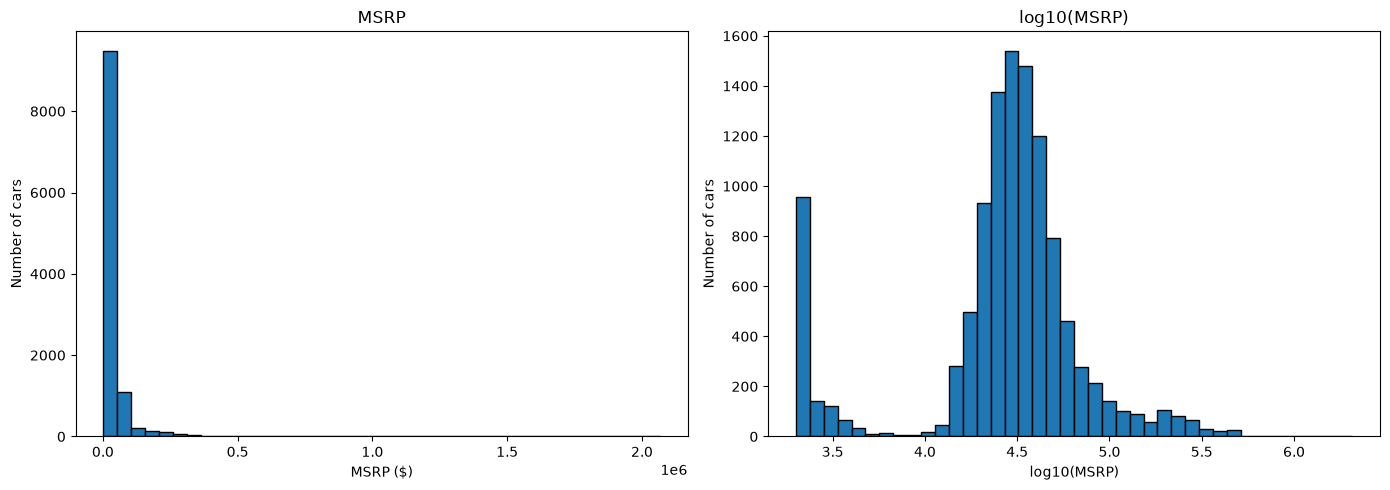

B: Histograms of MSRP and log10(MSRP)
The MSRP distribution is right-skewed, with a long tail of high-priced cars. The log transformation helps to normalize the distribution and make it more symmetric.
C: Share of cars above the mean MSRP
The share of cars above the mean is 26.7%


In [17]:
# a) mean and median
prices = clean["msrp"].dropna()
mean_msrp = prices.mean()
median_msrp = prices.median()

print("A: Mean and median MSRP")
print(f"Mean MSRP: ${mean_msrp:,.2f}")
print(f"Median MSRP: ${median_msrp:,.2f}")

# b) two histograms side by side (plt.subplots(1, 2))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(prices, bins=40, edgecolor="black")
axes[0].set_title("MSRP")
axes[0].set_xlabel("MSRP ($)")
axes[0].set_ylabel("Number of cars")

log_prices = np.log10(prices)
axes[1].hist(log_prices, bins=40, edgecolor="black")
axes[1].set_title("log10(MSRP)")
axes[1].set_xlabel("log10(MSRP)")
axes[1].set_ylabel("Number of cars")

plt.tight_layout()
plt.show()

print("B: Histograms of MSRP and log10(MSRP)")
print("The MSRP distribution is right-skewed, with a long tail of high-priced cars. The log transformation helps to normalize the distribution and make it more symmetric.")

# c) share of cars above the mean
share_above_mean = (prices > mean_msrp).mean()
print("C: Share of cars above the mean MSRP")
print(f"The share of cars above the mean is {share_above_mean:.1%}")

**Answer:** The median MSRP of $30,675 should be shown on the homepage. The MSRP distribution is strongly right-skewed, so a small number of unusually expensive cars pulls the mean up to $41,933.29; the median is more representative of a typical car because half of the cars cost less and half cost more.

### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [18]:
# Use trusted highway MPG values from 2017 cars only
cars_2017 = clean.loc[
    (clean["year"] == 2017)
    & clean["highway_mpg"].notna()
    & clean["vehicle_size"].notna()
].copy()

# a) mean and std of highway_mpg by vehicle_size, 2017 only
size_stats = (
    cars_2017.groupby("vehicle_size")["highway_mpg"]
    .agg(["count", "mean", "std"])
    .rename(columns={"mean": "mean_highway_mpg", "std": "std_highway_mpg"})
)

display(size_stats)

# b) z = (value - class mean) / class std
cars_2017["mpg_z"] = (
    cars_2017["highway_mpg"]
    - cars_2017.groupby("vehicle_size")["highway_mpg"].transform("mean")
) / cars_2017.groupby("vehicle_size")["highway_mpg"].transform("std")

# Show the Honda Civic and Volvo S90 comparisons
comparison = cars_2017[
    ((cars_2017["make"] == "Honda") & (cars_2017["model"] == "Civic"))
    | ((cars_2017["make"] == "Volvo") & (cars_2017["model"] == "S90"))
][["make", "model", "vehicle_size", "highway_mpg", "mpg_z"]]

display(comparison)

,count,mean_highway_mpg,std_highway_mpg
vehicle_size,,,
Compact,510,30.980392,6.449715
Large,468,22.991453,3.491184
Midsize,638,29.410658,5.452292


,make,model,vehicle_size,highway_mpg,mpg_z
2428,Honda,Civic,Compact,39.0,1.243405
2429,Honda,Civic,Compact,39.0,1.243405
2430,Honda,Civic,Compact,40.0,1.398451
2431,Honda,Civic,Compact,40.0,1.398451
2432,Honda,Civic,Compact,40.0,1.398451
2433,Honda,Civic,Compact,36.0,0.778268
2434,Honda,Civic,Midsize,42.0,2.309000
2435,Honda,Civic,Compact,40.0,1.398451
2436,Honda,Civic,Midsize,42.0,2.309000
2437,Honda,Civic,Compact,40.0,1.398451


**Answer:** The Honda Civic has higher raw highway fuel efficiency than the Volvo S90 in the examples being 42 MPG of the prior versus 34 MPG of the latter. However, the within-class z-score measures how unusual each car's MPG is relative to cars of the same size, so the Volvo S90 can be more impressive for its class even with a lower raw MPG. The repeated Civic and S90 rows are expected as the dataset contains multiple trims and configurations with different MPG values.

---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

2017 median MSRP: $36,738
95% bootstrap interval: $35,940–$37,683

Selected make: Lincoln (n=46)
Lincoln median MSRP: $46,060
95% bootstrap interval: $41,648–$49,025


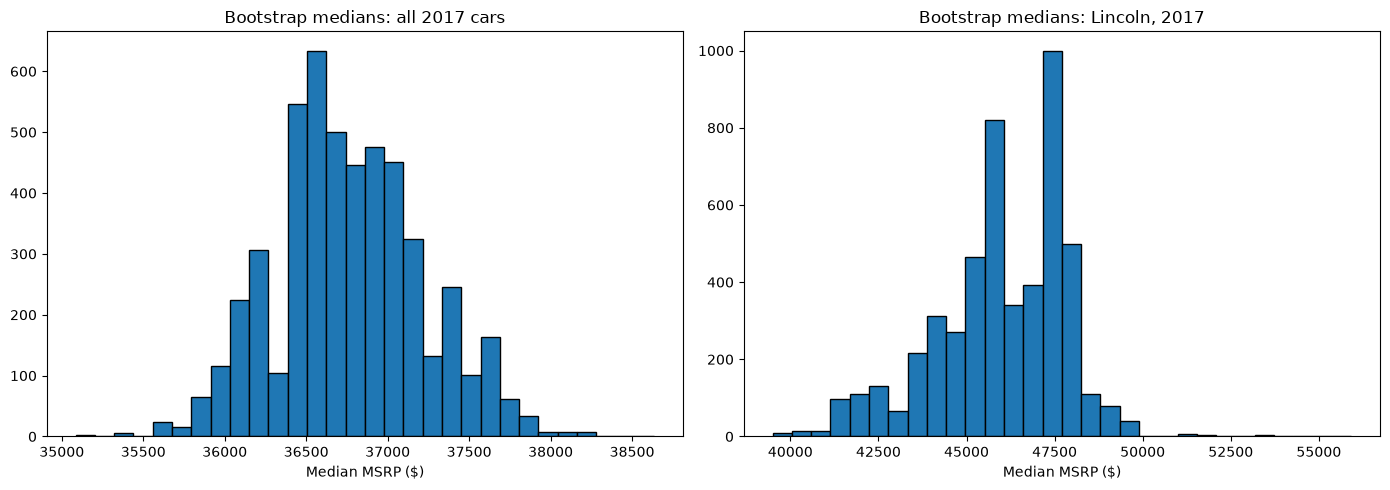

In [19]:
def bootstrap_median(values, n_boot=5000):
    """Return an array of bootstrap medians."""
    values = np.asarray(values)
    return np.array([
        np.median(rng.choice(values, size=len(values), replace=True))
        for _ in range(n_boot)
    ])

# a, b)
prices_2017 = clean.loc[
    (clean["year"] == 2017) & clean["msrp"].notna(), "msrp"
].to_numpy()

median_2017 = np.median(prices_2017)
boot_2017 = bootstrap_median(prices_2017)
ci_2017 = np.percentile(boot_2017, [2.5, 97.5])

print(f"2017 median MSRP: ${median_2017:,.0f}")
print(f"95% bootstrap interval: ${ci_2017[0]:,.0f}–${ci_2017[1]:,.0f}")

# c)
make_counts = (
    clean.loc[(clean["year"] == 2017) & clean["msrp"].notna()]
    .groupby("make")["msrp"]
    .size()
)
make = make_counts[make_counts < 50].idxmax()

make_prices = clean.loc[
    (clean["year"] == 2017)
    & (clean["make"] == make)
    & clean["msrp"].notna(),
    "msrp"
].to_numpy()

make_median = np.median(make_prices)
boot_make = bootstrap_median(make_prices)
ci_make = np.percentile(boot_make, [2.5, 97.5])

print(f"\nSelected make: {make} (n={len(make_prices)})")
print(f"{make} median MSRP: ${make_median:,.0f}")
print(f"95% bootstrap interval: ${ci_make[0]:,.0f}–${ci_make[1]:,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(boot_2017, bins=30, edgecolor="black")
axes[0].set_title("Bootstrap medians: all 2017 cars")
axes[0].set_xlabel("Median MSRP ($)")

axes[1].hist(boot_make, bins=30, edgecolor="black")
axes[1].set_title(f"Bootstrap medians: {make}, 2017")
axes[1].set_xlabel("Median MSRP ($)")

plt.tight_layout()
plt.show()

**Answer:** This interval represents the sampling uncertainty in estimating the typical 2017 car price from the observed data.

---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

Number of cars: 510
Mean highway MPG: 30.98
Median highway MPG: 30.00


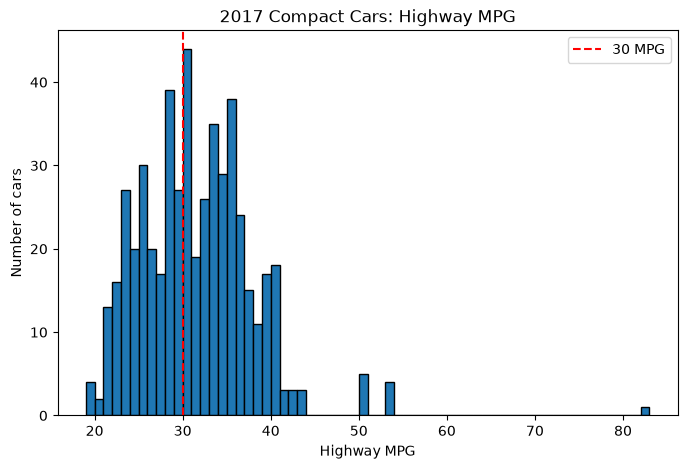

t-statistic: 3.433
p-value: 0.000323066

Rows per make-model:


make        model          
Toyota      Tacoma             27
Chevrolet   Corvette           24
Nissan      Frontier           22
            370Z               17
Porsche     911                14
Honda       Civic              13
Audi        A3                 12
Buick       Encore             10
Volkswagen  Golf GTI           10
Nissan      Juke               10
Chevrolet   Sonic              10
GMC         Terrain             9
Toyota      Corolla             9
Ford        Transit Connect     9
Hyundai     Tucson              8
dtype: int64

Number of unique make-models: 86
Model-level mean highway MPG: 32.27
Model-level t-statistic: 2.604
Model-level p-value: 0.00543081


In [20]:
# b) sample: 2017 compact cars (MPG you trust); n, mean, histogram
compact_2017 = clean.loc[
    (clean["year"] == 2017)
    & (clean["vehicle_size"] == "Compact")
    & clean["highway_mpg"].notna(),
    ["make", "model", "highway_mpg"]
].copy()

compact_mpg = compact_2017["highway_mpg"]

print(f"Number of cars: {len(compact_mpg)}")
print(f"Mean highway MPG: {compact_mpg.mean():.2f}")
print(f"Median highway MPG: {compact_mpg.median():.2f}")

plt.figure(figsize=(8, 5))
plt.hist(compact_mpg, bins=range(int(compact_mpg.min()), int(compact_mpg.max()) + 2),
         edgecolor="black")
plt.axvline(30, color="red", linestyle="--", label="30 MPG")
plt.xlabel("Highway MPG")
plt.ylabel("Number of cars")
plt.title("2017 Compact Cars: Highway MPG")
plt.legend()
plt.show()

# c) one-sample t-test vs 30
test_rows = stats.ttest_1samp(compact_mpg, 30, alternative="greater")
print(f"t-statistic: {test_rows.statistic:.3f}")
print(f"p-value: {test_rows.pvalue:.6g}")

# d) rows per make+model, then one row per model and retest
rows_per_model = (
    compact_2017.groupby(["make", "model"])
    .size()
    .sort_values(ascending=False)
)

print("\nRows per make-model:")
display(rows_per_model.head(15))

# Average to one observation per make-model
model_mpg = (
    compact_2017.groupby(["make", "model"])["highway_mpg"]
    .mean()
)

model_test = stats.ttest_1samp(model_mpg, 30, alternative="greater")

print(f"Number of unique make-models: {len(model_mpg)}")
print(f"Model-level mean highway MPG: {model_mpg.mean():.2f}")
print(f"Model-level t-statistic: {model_test.statistic:.3f}")
print(f"Model-level p-value: {model_test.pvalue:.6g}")

**Answer:** Let \(\mu\) be the true mean highway MPG for 2017 compact cars.  
- \(H_0: \mu \le 30\) MPG  
- \(H_a: \mu > 30\) MPG  

This is a one-sided test because marketing’s claim concerns only whether the mean exceeds 30 MPG, not whether it differs in either direction.

### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

In [21]:
# Keep only automatic/manual cars with valid prices
transmission_data = clean.loc[
    clean["transmission_type"].isin(["AUTOMATIC", "MANUAL"])
    & clean["msrp"].notna()
].copy()

# a) compare median MSRP by transmission type
print("Overall median MSRP:")
display(
    transmission_data.groupby("transmission_type")["msrp"]
    .agg(count="size", median="median", mean="mean")
)

# b) compare year by transmission type
print("\nYear distribution by transmission type:")
display(
    transmission_data.groupby("transmission_type")["year"]
    .agg(count="size", median="median", mean="mean", minimum="min", maximum="max")
)

# c) compare 2015-2017 medians overall and within each vehicle_size
recent = transmission_data[transmission_data["year"].between(2015, 2017)]

print("\n2015–2017 median MSRP:")
display(
    recent.groupby("transmission_type")["msrp"]
    .agg(count="size", median="median", mean="mean")
)

# Compare prices within each vehicle size
print("\n2015–2017 median MSRP by vehicle size:")
display(
    recent.groupby(["vehicle_size", "transmission_type"])["msrp"]
    .agg(count="size", median="median", mean="mean")
)

# For 2015-17 compacts, test automatic vs manual prices with:
# stats.mannwhitneyu(auto, manual)
compact_recent = recent[
    (recent["vehicle_size"] == "Compact")
    & recent["msrp"].notna()
]

auto = compact_recent.loc[
    compact_recent["transmission_type"] == "AUTOMATIC", "msrp"
]
manual = compact_recent.loc[
    compact_recent["transmission_type"] == "MANUAL", "msrp"
]

u_test = stats.mannwhitneyu(auto, manual, alternative="two-sided")

print("\n2015–2017 compact cars:")
print(f"Automatic: n={len(auto)}, median=${auto.median():,.0f}")
print(f"Manual:    n={len(manual)}, median=${manual.median():,.0f}")
print(f"Mann–Whitney U statistic: {u_test.statistic:.1f}")
print(f"p-value: {u_test.pvalue:.6g}")

Overall median MSRP:


,count,median,mean
transmission_type,,,
AUTOMATIC,7928,33007.5,41821.423184
MANUAL,2633,19385.0,28277.896316



Year distribution by transmission type:


,count,median,mean,minimum,maximum
transmission_type,,,,,
AUTOMATIC,7928,2015.0,2011.843340,1990,2017
MANUAL,2633,2008.0,2006.475503,1990,2017



2015–2017 median MSRP:


,count,median,mean
transmission_type,,,
AUTOMATIC,4511,37065.0,44766.363999
MANUAL,813,26905.0,38937.164822



2015–2017 median MSRP by vehicle size:


count   median          mean
vehicle_size transmission_type                              
Compact      AUTOMATIC           1119  25995.0  29320.674710
             MANUAL               589  25860.0  41113.140917
Large        AUTOMATIC           1473  44400.0  57351.930075
             MANUAL                26  38395.0  40680.384615
Midsize      AUTOMATIC           1919  37980.0  44112.475248
             MANUAL               198  26920.0  32235.277778


2015–2017 compact cars:
Automatic: n=1119, median=$25,995
Manual:    n=589, median=$25,860
Mann–Whitney U statistic: 317261.0
p-value: 0.204832


**Answer:** For 2015–2017 compact cars, manual cars have a slightly lower median MSRP, a difference of only $135. The Mann–Whitney U test gives p = 0.205, therefore lacking enough evidence to claim that manual cars are meaningfully cheaper; we should not market them as a budget option based on this comparison.

### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [22]:
# Keep only trusted highway MPG values and valid 2- or 4-door counts
door_data = clean.loc[
    clean["number_of_doors"].isin([2, 4])
    & clean["highway_mpg"].notna(),
    ["number_of_doors", "highway_mpg"]
]

mpg_4 = door_data.loc[door_data["number_of_doors"] == 4, "highway_mpg"]
mpg_2 = door_data.loc[door_data["number_of_doors"] == 2, "highway_mpg"]

# a) Welch t-test, 4-door vs 2-door
welch_test = stats.ttest_ind(mpg_4, mpg_2, equal_var=False)
mean_difference = mpg_4.mean() - mpg_2.mean()

print("a) Welch t-test")
print(f"4-door mean MPG: {mpg_4.mean():.2f}")
print(f"2-door mean MPG: {mpg_2.mean():.2f}")
print(f"Difference (4-door - 2-door): {mean_difference:.2f} MPG")
print(f"p-value: {welch_test.pvalue:.6g}")

# b) yearly gas cost = miles * price_per_gallon / mpg
miles_per_year = 12_000
price_per_gallon = 3.50
cost_4 = miles_per_year * price_per_gallon / mpg_4.mean()
cost_2 = miles_per_year * price_per_gallon / mpg_2.mean()
annual_savings = cost_2 - cost_4

print("\nb) Estimated annual savings")
print(f"Average 4-door driver saves: ${annual_savings:,.2f} per year")

# c) simulation
n_sims, hits = 1000, 0

for _ in range(n_sims):
    sample_4 = rng.choice(mpg_4.to_numpy(), size=30, replace=False)
    sample_2 = rng.choice(mpg_2.to_numpy(), size=30, replace=False)
    test = stats.ttest_ind(sample_4, sample_2, equal_var=False)

    if test.pvalue < 0.05:
        hits += 1

significant_fraction = hits / n_sims
print("\nc) Simulation")
print(f"Significant tests: {hits}/{n_sims}")
print(f"Fraction significant: {significant_fraction:.1%}")

# d) Recommendation
print("\nd) Recommendation")
print("Avoid the unqualified ad claim; report the MPG difference and estimated savings instead.")

a) Welch t-test
4-door mean MPG: 26.92
2-door mean MPG: 25.26
Difference (4-door - 2-door): 1.66 MPG
p-value: 2.26006e-35

b) Estimated annual savings
Average 4-door driver saves: $102.76 per year

c) Simulation
Significant tests: 140/1000
Fraction significant: 14.0%

d) Recommendation
Avoid the unqualified ad claim; report the MPG difference and estimated savings instead.


**Answer:** 4-door cars had slightly better average fuel economy than 2-door cars, but fuel efficiency is comparable by vehicle.

---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

**Memo:** Manual cars appear to cost slightly less, but the difference is not large enough to support a strong pricing premium or discount; the dataset contains 2,935 manual cars compared with 8,266 automatic cars. Another relevant discovery related to price is that automatic cars are much more common, so demand and inventory but not transmission alone may explain part of the price difference. The data also include 720 duplicate rows, and some fields are missing, so the averages may be affected by repeated or incomplete records. Because this is observational data, it shows a connection rather than proving that having a manual transmission causes a car to cost less.

---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

In [23]:
# S1

### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [24]:
# S2